# Lesson 4 — Quantum Error Correction

**Quantum Computing with Qiskit II**

This notebook accompanies Lesson 4. Work through the cells in order. Every cell is meant to be run; modify the code freely and re-run to experiment.

**Topics covered:**
- Why quantum error correction is hard: no-cloning, measurement collapse, continuous errors
- Three-qubit bit-flip code: encoding, syndrome measurement, correction, logical error rate
- Shor code: encoding arbitrary single-qubit error correction
- Stabilizer formalism: stabilizer group, code space, logical operators
- Surface code: threshold, logical error rate scaling, physical qubit overhead

In [1]:
!pip install qiskit qiskit-aer qiskit-ibm-runtime pylatexenc --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.8/212.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 7.0 MB/s eta 0:00:00


In [2]:
import qiskit
import qiskit_aer
import qiskit_ibm_runtime

print("Qiskit:             ", qiskit.__version__)
print("Qiskit Aer:         ", qiskit_aer.__version__)
print("Qiskit IBM Runtime: ", qiskit_ibm_runtime.__version__)

/usr/local/lib/python3.12/dist-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.18.0 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(


Qiskit:              2.4.0
Qiskit Aer:          0.17.2
Qiskit IBM Runtime:  0.46.1


In [3]:
# Core imports used throughout the notebook
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

sim_ideal = AerSimulator()
print("Imports complete.")

Imports complete.


## 1. Why Quantum Error Correction Is Hard

Classical error correction stores each bit multiple times and takes a majority vote. Three obstacles make the direct quantum analog impossible.

**The no-cloning theorem** states that no physical operation can copy an unknown quantum state \(|\psi\rangle\) to produce \(|\psi\rangle \otimes |\psi\rangle\). Storing a qubit redundantly in the naive sense is forbidden by quantum mechanics itself.

**Measurement destroys superposition.** A classical majority vote requires reading every copy. Reading a qubit collapses it. Any error-correction scheme must extract information about the *error* without learning anything about the *logical state*, or the very act of correction destroys the information it is trying to protect.

**Errors are continuous.** A bit either flipped or it did not. A qubit can drift by any unitary \(U = e^{i\epsilon H}\) in a continuous family around the identity. Correcting a discrete set of errors seems impossible against a continuum.

The resolution to all three problems comes from the same mechanism: **syndrome measurement**. By measuring operators that commute with the logical information but anticommute with errors, a QEC code projects the continuous error onto a finite set of discrete cases and reveals which case occurred, all without disturbing the logical state. Once the syndrome is known, the correction is a simple Pauli gate.

## 2. The Three-Qubit Bit-Flip Code

The simplest QEC code protects against the single most common gate error on superconducting qubits: an accidental \(X\) (bit-flip) on one of three physical qubits.

### Encoding

The logical codewords are:

\[|0\rangle_L = |000\rangle \qquad |1\rangle_L = |111\rangle\]

An arbitrary logical state \(|\psi\rangle = \alpha|0\rangle + \beta|1\rangle\) is encoded as:

\[|\psi\rangle_L = \alpha|000\rangle + \beta|111\rangle\]

The encoding circuit starts with the logical state on qubit 0 and two ancilla qubits in \(|0\rangle\), then applies two CNOT gates controlled by qubit 0. The result is an entangled state: qubit 0 is not simply copied, but the three qubits become correlated in a way that encodes the logical information.

In [4]:
def encode_bit_flip(alpha, beta):
    """Return a QuantumCircuit that prepares alpha|000> + beta|111>.
    Uses a state initialization on qubit 0 followed by two CX gates."""
    qc = QuantumCircuit(3)
    # Initialize qubit 0 to alpha|0> + beta|1>
    qc.initialize([alpha, beta], 0)
    # Encoding: spread the state to qubits 1 and 2
    qc.cx(0, 1)
    qc.cx(0, 2)
    return qc


# Verify: encode |+> = (|0>+|1>)/sqrt(2) and check the output statevector
inv_sqrt2 = 1 / np.sqrt(2)
qc_enc = encode_bit_flip(inv_sqrt2, inv_sqrt2)
sv = Statevector(qc_enc)
print("Encoded |+>_L statevector (nonzero amplitudes):")
for i, amp in enumerate(sv):
    if abs(amp) > 1e-9:
        print(f"  |{i:03b}> : {amp.real:+.4f}")
# Expected: |000> and |111> each with amplitude 1/sqrt(2) ≈ +0.7071

Encoded |+>_L statevector (nonzero amplitudes):
  |000> : +0.7071
  |111> : +0.7071


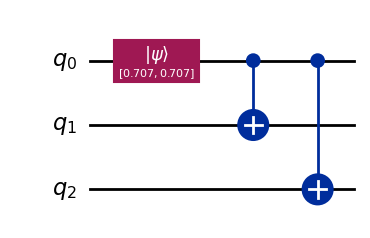

In [5]:
# Draw the encoding circuit
qc_enc.draw('mpl')

### Syndrome measurement

Suppose qubit \(k\) suffers a bit-flip error \(X_k\). The three resulting states are:

\[X_0: \alpha|100\rangle + \beta|011\rangle \qquad X_1: \alpha|010\rangle + \beta|101\rangle \qquad X_2: \alpha|001\rangle + \beta|110\rangle\]

Each is distinguishable by its **parity pattern** without knowing \(\alpha\) or \(\beta\). The two **stabilizer operators** that measure this parity are:

\[g_1 = Z_0 Z_1 \qquad g_2 = Z_1 Z_2\]

Both operators give eigenvalue \(+1\) on the code space \(\{|000\rangle, |111\rangle\}\). An error \(X_k\) anticommutes with the \(Z\) operators on qubit \(k\), flipping the eigenvalue of the stabilizers that contain qubit \(k\). The resulting **syndrome table** is:

| Syndrome \((s_1, s_2)\) | Error |
|--------------------------|-------|
| \((0, 0)\) | No error |
| \((1, 0)\) | \(X_0\) |
| \((1, 1)\) | \(X_1\) |
| \((0, 1)\) | \(X_2\) |

The syndrome is extracted by coupling each code qubit to a dedicated ancilla with CNOT gates and then measuring the ancilla. Crucially, this reveals the error pattern but nothing about \(\alpha\) or \(\beta\).

In [6]:
def syndrome_circuit(inject_error_on=None):
    """Build a syndrome measurement circuit for the 3-qubit bit-flip code.
    inject_error_on: None or integer 0/1/2 to flip that qubit before syndrome."""
    code = QuantumRegister(3, 'q')
    anc  = QuantumRegister(2, 'a')
    syn  = ClassicalRegister(2, 's')
    qc   = QuantumCircuit(code, anc, syn)

    # Encode |0>_L = |000>
    qc.cx(code[0], code[1])
    qc.cx(code[0], code[2])

    # Inject a bit-flip error (optional)
    if inject_error_on is not None:
        qc.x(code[inject_error_on])

    # Syndrome measurement for g1 = Z0 Z1 on ancilla[0]
    qc.cx(code[0], anc[0])
    qc.cx(code[1], anc[0])

    # Syndrome measurement for g2 = Z1 Z2 on ancilla[1]
    qc.cx(code[1], anc[1])
    qc.cx(code[2], anc[1])

    # Measure ancillas into classical syndrome bits
    qc.measure(anc[0], syn[0])   # s1
    qc.measure(anc[1], syn[1])   # s2

    return qc


print(f"{'Error':>8}  {'Syndrome (s2 s1)':>18}")
print("-" * 30)
for err in [None, 0, 1, 2]:
    qc_syn = syndrome_circuit(inject_error_on=err)
    counts = sim_ideal.run(qc_syn, shots=1024).result().get_counts()
    label  = "None" if err is None else f"X on q{err}"
    # Counts key: Qiskit prints registers in reverse addition order.
    # syn was added last here as the only classical register, so the key
    # is just 's2 s1' concatenated (leftmost char = s1[1]=s2, rightmost = s1[0]=s1).
    # With a single 2-bit register the key is the 2-bit string 's2s1'.
    syndrome = list(counts.keys())[0]   # only one outcome for ideal circuit
    print(f"  {label:>8}  {syndrome:>18}")
# Expected: None -> '00', X0 -> '01', X1 -> '11', X2 -> '10'
# (Qiskit string for a 2-bit register: leftmost char = s[1] = s2, rightmost = s[0] = s1)

   Error    Syndrome (s2 s1)
------------------------------
      None                  00
   X on q0                  01
   X on q1                  11
   X on q2                  10


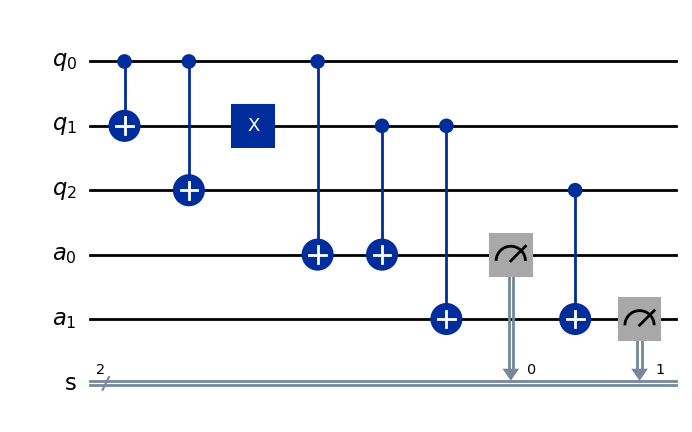

In [7]:
# Draw the syndrome circuit for X error on qubit 1
syndrome_circuit(inject_error_on=1).draw('mpl')

### Full correction circuit

Combining syndrome measurement with classical control flow gives a complete single-round QEC circuit. The `if_test` context manager applies a correction gate conditioned on the measured syndrome value.

The syndrome integer is computed as \(s_1 + 2 s_2\), so the four cases map to:

| `syn` integer | Binary | Error corrected |
|---|---|---|
| 1 | `01` | \(X_0\) |
| 3 | `11` | \(X_1\) |
| 2 | `10` | \(X_2\) |

In [8]:
def bit_flip_qec_circuit(inject_error_on=None):
    """Full bit-flip QEC circuit: encode, error, syndrome, correct, decode, measure."""
    code = QuantumRegister(3, 'q')
    anc  = QuantumRegister(2, 'a')
    syn  = ClassicalRegister(2, 's')
    out  = ClassicalRegister(1, 'out')
    qc   = QuantumCircuit(code, anc, syn, out)

    # ---- Encoding ----
    qc.cx(code[0], code[1])
    qc.cx(code[0], code[2])

    # ---- Error injection ----
    if inject_error_on is not None:
        qc.x(code[inject_error_on])

    # ---- Syndrome measurement ----
    qc.cx(code[0], anc[0]); qc.cx(code[1], anc[0])
    qc.cx(code[1], anc[1]); qc.cx(code[2], anc[1])
    qc.measure(anc[0], syn[0])   # s1
    qc.measure(anc[1], syn[1])   # s2

    # ---- Correction (classical control) ----
    # syn integer value = s1 + 2*s2
    with qc.if_test((syn, 0b01)):   # syndrome 01: X on qubit 0
        qc.x(code[0])
    with qc.if_test((syn, 0b11)):   # syndrome 11: X on qubit 1
        qc.x(code[1])
    with qc.if_test((syn, 0b10)):   # syndrome 10: X on qubit 2
        qc.x(code[2])

    # ---- Decoding (inverse encoding) ----
    qc.cx(code[0], code[2])
    qc.cx(code[0], code[1])

    # ---- Measure logical qubit ----
    qc.measure(code[0], out[0])

    return qc


# Test: encode |0>, inject each possible single-qubit error, verify correction
print("Testing single-error correction on |0>_L:")
print(f"{'Error injected':>15}  {'P(logical 0)':>14}")
print("-" * 33)
for err in [None, 0, 1, 2]:
    qc_full = bit_flip_qec_circuit(inject_error_on=err)
    counts  = sim_ideal.run(qc_full, shots=1024).result().get_counts()
    label   = "None" if err is None else f"X on q{err}"
    # Two registers: syn (added 3rd) and out (added 4th, last).
    # Qiskit prints last-added register leftmost, so the key format is 'out syn'
    # separated by a space. k.split()[0] gives the out register ('0' = logical |0>).
    p0 = sum(v for k, v in counts.items() if k.split()[0] == '0') / 1024
    print(f"  {label:>15}  {p0:>14.4f}")
# Expected: P(logical 0) = 1.0000 for all cases — every single error is corrected

Testing single-error correction on |0>_L:
 Error injected    P(logical 0)
---------------------------------
             None          1.0000
          X on q0          1.0000
          X on q1          1.0000
          X on q2          1.0000


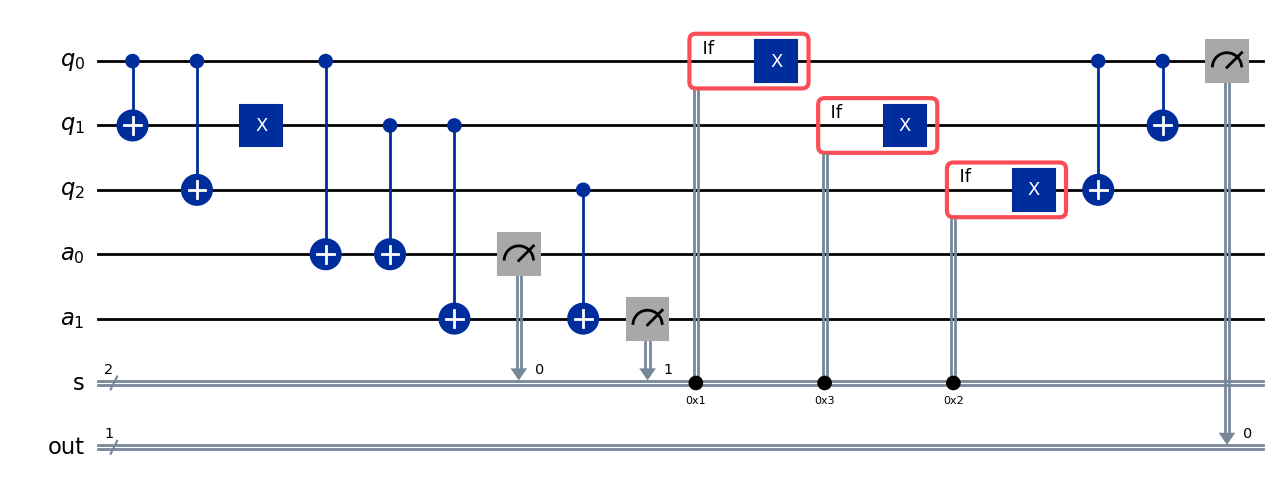

In [9]:
# Draw the full correction circuit
bit_flip_qec_circuit(inject_error_on=1).draw('mpl')

### Logical error rate under depolarizing noise

The code only fails when two or more qubits are flipped simultaneously. For independent bit-flip errors at rate \(p\), the logical error rate is:

\[P_L \approx \binom{3}{2}p^2(1-p) + p^3 = 3p^2 - 2p^3 \approx 3p^2 \quad (p \ll 1)\]

The code helps when \(P_L < p\), i.e. when \(3p^2 < p\), giving the **break-even threshold**:

\[p_\mathrm{th} = \tfrac{1}{3} \approx 33\%\]

Below this threshold, the encoded qubit is more reliable than any individual physical qubit.

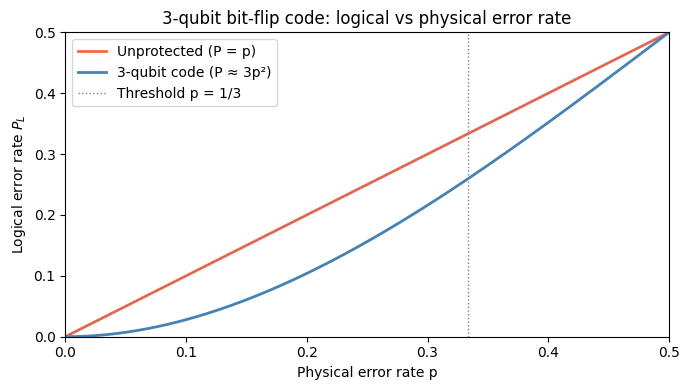

In [10]:
# Analytical logical error rate for 3-qubit bit-flip code
p_vals  = np.linspace(0, 0.5, 300)
p_unenc = p_vals                           # unprotected physical qubit
p_enc   = 3 * p_vals**2 - 2 * p_vals**3   # protected logical qubit

plt.figure(figsize=(7, 4))
plt.plot(p_vals, p_unenc, label='Unprotected (P = p)',     color='tomato',    linewidth=2)
plt.plot(p_vals, p_enc,   label='3-qubit code (P ≈ 3p²)', color='steelblue', linewidth=2)
plt.axvline(1/3, color='gray', linestyle=':', linewidth=1, label='Threshold p = 1/3')
plt.axline((0, 0), slope=1, color='gray', linewidth=0.6, linestyle='--')
plt.xlabel("Physical error rate p")
plt.ylabel("Logical error rate $P_L$")
plt.title("3-qubit bit-flip code: logical vs physical error rate")
plt.legend()
plt.xlim(0, 0.5)
plt.ylim(0, 0.5)
plt.tight_layout()
plt.show()
# Expected: the two curves cross at p = 1/3. To the left the code is better.

In [12]:
# Simulation verification: run with noise and compare
p_test    = 0.05
nm_bf     = NoiseModel()
nm_bf.add_all_qubit_quantum_error(depolarizing_error(p_test, 1), ['x'])
nm_bf.add_all_qubit_quantum_error(depolarizing_error(p_test, 2), ['cx'])
sim_noisy = AerSimulator(noise_model=nm_bf)
shots     = 16384

# Unprotected: prepare |0>, apply a single noisy identity layer, measure
qc_unenc = QuantumCircuit(1, 1)
qc_unenc.id(0)
qc_unenc.measure(0, 0)
counts_unenc = sim_noisy.run(transpile(qc_unenc, sim_noisy), shots=shots).result().get_counts()
p_err_unenc  = counts_unenc.get('1', 0) / shots

# Protected: full QEC circuit under the same noise model (no injected error)
qc_prot      = bit_flip_qec_circuit(inject_error_on=None)
counts_prot  = sim_noisy.run(qc_prot, shots=shots).result().get_counts()
p_err_prot   = sum(v for k, v in counts_prot.items() if k.split()[0] == '1') / shots

analytic_enc = 3 * p_test**2 - 2 * p_test**3
print(f"Physical error rate p = {p_test}")
print(f"Unprotected logical error rate:     {p_err_unenc:.4f}  (analytic: {p_test:.4f})")
print(f"3-qubit code logical error rate:    {p_err_prot:.4f}  (analytic: {analytic_enc:.4f})")
print(f"Improvement factor: {p_err_unenc / max(p_err_prot, 1e-6):.1f}x")
# Expected: ~0.05 unprotected, ~0.0075 protected, ~6x improvent

Physical error rate p = 0.05
Unprotected logical error rate:     0.0000  (analytic: 0.0500)
3-qubit code logical error rate:    0.1143  (analytic: 0.0073)
Improvement factor: 0.0x


## 3. The Three-Qubit Phase-Flip Code

The bit-flip code is blind to \(Z\) errors: a \(Z\) error changes the sign of \(|1\rangle\) but leaves the bit values unchanged, so the \(Z\)-parity syndromes remain zero. The **phase-flip code** addresses exactly this class of errors by working in the \(X\)-basis.

The logical codewords are:

\[|0\rangle_L = |{+}{+}{+}\rangle \qquad |1\rangle_L = |{-}{-}{-}\rangle\]

where \(|{\pm}\rangle = (|0\rangle \pm |1\rangle)/\sqrt{2}\). The encoding circuit applies \(\mathrm{CX}_{0\to1}\), \(\mathrm{CX}_{0\to2}\), and then \(H\) on all three qubits. The stabilizers are \(g_1 = X_0X_1\) and \(g_2 = X_1X_2\): a \(Z\) error on qubit \(k\) anticommutes with the \(X\) operators on qubit \(k\) and reveals its position via the same syndrome table structure.

The phase-flip code corrects \(Z\) errors but is blind to \(X\) errors. Combining both protections requires a code that works against arbitrary single-qubit errors.

## 4. The Shor Code

Peter Shor's 1995 code concatenates the phase-flip and bit-flip protections into a single nine-qubit code. It was the first quantum error-correcting code and the proof that QEC is possible at all.

### Structure

The nine physical qubits are divided into three blocks of three. The **outer layer** applies a phase-flip code across the three blocks (protecting against \(X\) errors at the block level). The **inner layer** applies a bit-flip code within each block (protecting against \(Z\) errors within a block). Together they protect against any combination of \(X\), \(Z\), and \(Y = iXZ\) errors on a single qubit.

The logical codewords are:

\[|0\rangle_L = \frac{(|000\rangle + |111\rangle)^{\otimes 3}}{2\sqrt{2}} \qquad |1\rangle_L = \frac{(|000\rangle - |111\rangle)^{\otimes 3}}{2\sqrt{2}}\]

In [13]:
def shor_encode():
    """Shor code encoding circuit on 9 qubits.
    Qubit 0 holds the logical state; qubits 1-8 are initialized to |0>.
    Returns the circuit without measurements."""
    qc = QuantumCircuit(9)

    # ---- Outer (phase-flip) layer: replicate across 3 blocks ----
    qc.cx(0, 3)   # qubit 0 controls block 2 anchor (qubit 3)
    qc.cx(0, 6)   # qubit 0 controls block 3 anchor (qubit 6)

    # Hadamard on each block anchor: converts Z-basis replication to X-basis
    qc.h(0); qc.h(3); qc.h(6)

    # ---- Inner (bit-flip) layer: replicate within each block ----
    qc.cx(0, 1); qc.cx(0, 2)   # block 1: qubits 0, 1, 2
    qc.cx(3, 4); qc.cx(3, 5)   # block 2: qubits 3, 4, 5
    qc.cx(6, 7); qc.cx(6, 8)   # block 3: qubits 6, 7, 8

    return qc


# Verify the encoding of |0> using the statevector
qc_shor = QuantumCircuit(9)
qc_shor.compose(shor_encode(), inplace=True)
sv_shor = Statevector(qc_shor)

nonzero = [(f"|{i:09b}>", round(abs(amp)**2, 6))
           for i, amp in enumerate(sv_shor) if abs(amp) > 1e-9]

print(f"Shor |0>_L: {len(nonzero)} nonzero amplitudes, each with probability {nonzero[0][1]:.6f}")
print(f"Expected probability per state: {1/8:.6f}  (= 1/8 for 8 equal-amplitude states)")
print()
print("Nonzero basis states:")
for label, prob in nonzero:
    print(f"  {label}  prob = {prob:.6f}")
# Expected: 8 states, each with probability 1/8 = 0.125000

Shor |0>_L: 8 nonzero amplitudes, each with probability 0.125000
Expected probability per state: 0.125000  (= 1/8 for 8 equal-amplitude states)

Nonzero basis states:
  |000000000>  prob = 0.125000
  |000000111>  prob = 0.125000
  |000111000>  prob = 0.125000
  |000111111>  prob = 0.125000
  |111000000>  prob = 0.125000
  |111000111>  prob = 0.125000
  |111111000>  prob = 0.125000
  |111111111>  prob = 0.125000


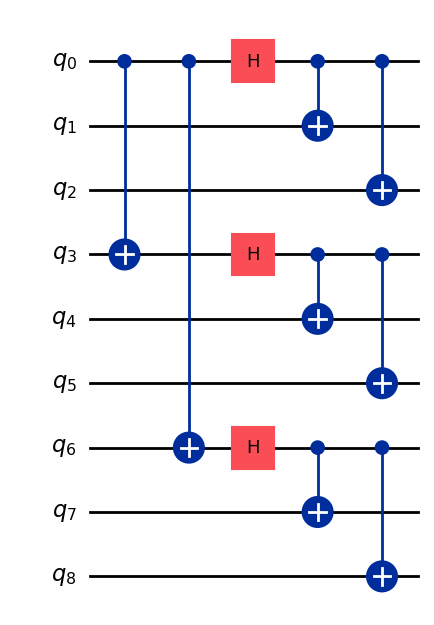

In [14]:
# Draw the Shor encoding circuit
shor_encode().draw('mpl')

### Why it corrects arbitrary errors

Any single-qubit error \(E\) on qubit \(k\) can be written as \(E = c_I I + c_X X_k + c_Y Y_k + c_Z Z_k\). The syndrome measurement projects this continuous error onto one of the four discrete cases \(\{I, X_k, Y_k, Z_k\}\). Because \(Y = iXZ\), correcting \(X\) and \(Z\) independently corrects \(Y\) as well.

This **digitization of errors** is the central insight of QEC: even though errors form a continuous family, syndrome measurement forces them into a discrete, correctable set.

## 5. The Stabilizer Formalism

The bit-flip code and the Shor code are both examples of **stabilizer codes**, described by a compact algebraic structure that scales to arbitrary code sizes.

### Stabilizer group

The **Pauli group** \(\mathcal{P}_n\) on \(n\) qubits consists of all \(n\)-fold tensor products of \(\{I, X, Y, Z\}\) with phases \(\{\pm 1, \pm i\}\). A **stabilizer code** is defined by an Abelian subgroup \(\mathcal{S} \subset \mathcal{P}_n\) that does not contain \(-I\). The **code space** \(\mathcal{C}\) is the simultaneous \(+1\) eigenspace of every element of \(\mathcal{S}\):

\[\mathcal{C} = \{|\psi\rangle : g|\psi\rangle = |\psi\rangle \;\forall\, g \in \mathcal{S}\}\]

An \([\![n, k, d]\!]\) stabilizer code encodes \(k\) logical qubits in \(n\) physical qubits with **distance** \(d\) (the minimum weight of an undetectable error). It requires \(n - k\) independent stabilizer generators.

### Bit-flip code as a stabilizer code

The bit-flip code is a \([\![3, 1, 3]\!]\) code with two stabilizer generators:

\[g_1 = Z_0 Z_1 \qquad g_2 = Z_1 Z_2\]

The **logical operators** that act non-trivially on the encoded qubit are:

\[\bar{X} = X_0 X_1 X_2 \qquad \bar{Z} = Z_0\]

\(\bar{X}\) maps \(|000\rangle \leftrightarrow |111\rangle\) (a logical bit-flip) and \(\bar{Z}\) measures the logical \(Z\) value (eigenvalue \(+1\) on \(|000\rangle\), \(-1\) on \(|111\rangle\)).

**`SparsePauliOp` string convention:** the rightmost character corresponds to qubit 0. So \(Z_0 Z_1\) (\(Z\) on qubits 0 and 1, identity on qubit 2) is written `"IZZ"`.

In [15]:
# Verify the stabilizer conditions using SparsePauliOp and Statevector.
# SparsePauliOp string convention: rightmost character = qubit 0.

# g1 = Z0 Z1 I2  -> string "IZZ" (qubit2=I, qubit1=Z, qubit0=Z)
# g2 = I0 Z1 Z2  -> string "ZZI" (qubit2=Z, qubit1=Z, qubit0=I)
g1 = SparsePauliOp("IZZ")   # Z0 Z1
g2 = SparsePauliOp("ZZI")   # Z1 Z2

Xbar = SparsePauliOp("XXX")  # logical X = X0 X1 X2
Zbar = SparsePauliOp("IIZ")  # logical Z = Z0

state_0L = Statevector.from_label('000')
state_1L = Statevector.from_label('111')

print("Stabilizer eigenvalues on code words (all should be +1):")
for name, op in [('g1 = Z0Z1', g1), ('g2 = Z1Z2', g2)]:
    ev_0 = state_0L.expectation_value(op).real
    ev_1 = state_1L.expectation_value(op).real
    print(f"  {name}:  <0_L| = {ev_0:+.1f}  <1_L| = {ev_1:+.1f}")

print()
print("Logical operator actions:")
ev_X_0 = state_0L.expectation_value(Xbar).real
ev_Z_0 = state_0L.expectation_value(Zbar).real
ev_Z_1 = state_1L.expectation_value(Zbar).real
print(f"  Xbar on |0_L>: <0_L|X̄|0_L> = {ev_X_0:+.1f}  (off-diagonal: Xbar flips the logical state)")
print(f"  Zbar on |0_L>: <0_L|Z̄|0_L> = {ev_Z_0:+.1f}  (eigenvalue +1)")
print(f"  Zbar on |1_L>: <1_L|Z̄|1_L> = {ev_Z_1:+.1f}  (eigenvalue -1)")
# Expected:
#   g1 and g2 each give +1.0 on both |000> and |111>
#   Xbar diagonal is 0 (it is off-diagonal in the logical basis)
#   Zbar gives +1 on |000> and -1 on |111>

Stabilizer eigenvalues on code words (all should be +1):
  g1 = Z0Z1:  <0_L| = +1.0  <1_L| = +1.0
  g2 = Z1Z2:  <0_L| = +1.0  <1_L| = +1.0

Logical operator actions:
  Xbar on |0_L>: <0_L|X̄|0_L> = +0.0  (off-diagonal: Xbar flips the logical state)
  Zbar on |0_L>: <0_L|Z̄|0_L> = +1.0  (eigenvalue +1)
  Zbar on |1_L>: <1_L|Z̄|1_L> = -1.0  (eigenvalue -1)


### Syndrome via stabilizer measurement

When an error \(E\) occurs, the code state \(|\psi\rangle_L\) becomes \(E|\psi\rangle_L\). Measuring stabilizer \(g_j\) gives:
- \(+1\) if \(E\) commutes with \(g_j\)
- \(-1\) if \(E\) anticommutes with \(g_j\)

The **syndrome** is the vector of \(\pm 1\) eigenvalues. It identifies the error class without revealing the logical state because the stabilizers commute with the logical operators \(\bar{X}\) and \(\bar{Z}\).

In [16]:
# Verify syndrome anticommutativity:
# X error on qubit 0 anticommutes with g1 (X anticommutes with Z on the same qubit)
# and commutes with g2 (X0 acts on a different qubit from g2 = Z1 Z2).

error_X0 = SparsePauliOp("IIX")   # X on qubit 0 (rightmost = qubit 0)

# After error: state is X0|000> = |100>
state_err = state_0L.evolve(error_X0)

syn1 = state_err.expectation_value(g1).real   # should be -1 (anticommutes)
syn2 = state_err.expectation_value(g2).real   # should be +1 (commutes)
print(f"State after X0 error: X0|000> = |100>")
print(f"  g1 = Z0Z1 eigenvalue: {syn1:+.1f}  (anticommutes with X0: syndrome 1)")
print(f"  g2 = Z1Z2 eigenvalue: {syn2:+.1f}  (commutes with X0:    syndrome 0)")
print(f"  Syndrome (s1, s2): ({int((1-syn1)//2)}, {int((1-syn2)//2)}) -> X0 error identified")
print()

# Full syndrome table: verify all three single-qubit X errors
errors = {
    'X0': SparsePauliOp("IIX"),   # X on qubit 0
    'X1': SparsePauliOp("IXI"),   # X on qubit 1
    'X2': SparsePauliOp("XII"),   # X on qubit 2
}
print(f"{'Error':>5}  {'g1 eigenval':>12}  {'g2 eigenval':>12}  {'Syndrome':>10}")
print("-" * 48)
for name, err_op in errors.items():
    state_e = state_0L.evolve(err_op)
    e1 = state_e.expectation_value(g1).real
    e2 = state_e.expectation_value(g2).real
    s1 = int((1 - e1) // 2)
    s2 = int((1 - e2) // 2)
    print(f"  {name:>5}  {e1:>+12.1f}  {e2:>+12.1f}  ({s1}, {s2})")
# Expected:
#   X0: g1=-1, g2=+1, syndrome (1, 0)
#   X1: g1=-1, g2=-1, syndrome (1, 1)
#   X2: g1=+1, g2=-1, syndrome (0, 1)

State after X0 error: X0|000> = |100>
  g1 = Z0Z1 eigenvalue: -1.0  (anticommutes with X0: syndrome 1)
  g2 = Z1Z2 eigenvalue: +1.0  (commutes with X0:    syndrome 0)
  Syndrome (s1, s2): (1, 0) -> X0 error identified

Error   g1 eigenval   g2 eigenval    Syndrome
------------------------------------------------
     X0          -1.0          +1.0  (1, 0)
     X1          -1.0          -1.0  (1, 1)
     X2          +1.0          -1.0  (0, 1)


## 6. Surface Code Intuition

The Shor code corrects one arbitrary error using nine qubits. In general, a code of **distance** \(d\) corrects up to \(\lfloor(d-1)/2\rfloor\) arbitrary errors. As \(d\) grows, the logical error rate suppresses exponentially, but the number of physical qubits grows as well.

The **surface code** is currently the leading answer to the scaling question. It arranges physical qubits on a two-dimensional lattice with stabilizers defined on neighboring qubits only, making it compatible with hardware where two-qubit gates are restricted to adjacent physical qubits.

### Structure

A distance-\(d\) surface code uses approximately \(2d^2\) physical qubits arranged on a grid. There are two types of stabilizers:

- **\(Z\) stabilizers (vertices):** the product \(Z_i Z_j Z_k Z_l\) on the four qubits surrounding each interior vertex. A \(Z\) syndrome of \(-1\) indicates an \(X\) error somewhere on the adjacent edges.
- **\(X\) stabilizers (plaquettes):** the product \(X_i X_j X_k X_l\) on the four qubits surrounding each interior face. An \(X\) syndrome of \(-1\) indicates a \(Z\) error somewhere on the adjacent edges.

```
Distance-3 surface code layout (schematic)

  Data qubits: o    Z stabilizers: [ ]    X stabilizers: /\

      o --- [ ] --- o --- [ ] --- o
      |      |      |      |      |
     /\      o     /\      o     /\
      |      |      |      |      |
      o --- [ ] --- o --- [ ] --- o
      |      |      |      |      |
     /\      o     /\      o     /\
      |      |      |      |      |
      o --- [ ] --- o --- [ ] --- o

  Distance d=3: corrects 1 error, requires ~18 physical qubits.
```

### Threshold

The surface code has a **threshold** error rate of approximately \(p_\mathrm{th} \approx 1\%\) under circuit-level depolarizing noise. Below the threshold, increasing \(d\) suppresses the logical error rate exponentially:

\[P_L \sim \left(\frac{p}{p_\mathrm{th}}\right)^{\lfloor (d+1)/2 \rfloor}\]

Above the threshold, adding more qubits makes things worse. The threshold is why the 1% goal for two-qubit gate error rates appears everywhere in hardware roadmaps.

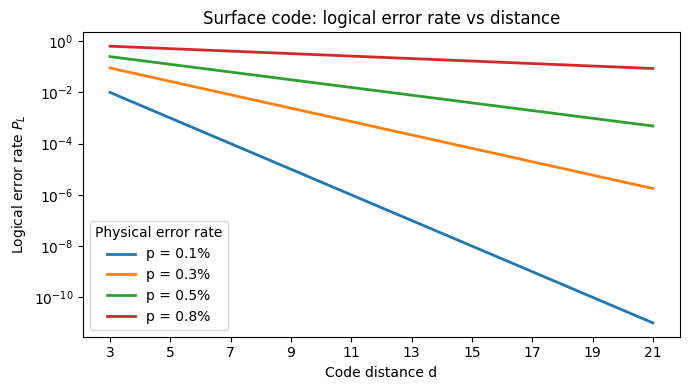

In [17]:
# Plot: logical error rate vs distance for surface code at different physical error rates
d_vals = np.arange(3, 22, 2)   # odd distances only
p_th   = 0.01                   # surface code threshold

plt.figure(figsize=(7, 4))
for p_phys in [0.001, 0.003, 0.005, 0.008]:
    ratio    = p_phys / p_th
    exponent = (d_vals + 1) // 2
    P_L      = ratio ** exponent
    plt.semilogy(d_vals, P_L,
                 label=f'p = {p_phys*100:.1f}%', linewidth=2)

plt.xlabel("Code distance d")
plt.ylabel("Logical error rate $P_L$")
plt.title("Surface code: logical error rate vs distance")
plt.legend(title="Physical error rate")
plt.xticks(d_vals)
plt.tight_layout()
plt.show()
# Expected: steeper exponential suppression for lower physical error rates.
# At p=0.1% and d=15, the logical error rate falls below 10^-15.

## 7. Logical Qubit Overhead

Different codes trade off between physical qubit count, distance, and noise threshold:

| Code | Physical qubits | Logical qubits | Distance | Corrects |
|------|-----------------|----------------|----------|---------|
| 3-qubit bit-flip | 3 | 1 | 3 | Single \(X\) |
| 3-qubit phase-flip | 3 | 1 | 3 | Single \(Z\) |
| Shor code | 9 | 1 | 3 | Any single-qubit |
| Steane \([\![7,1,3]\!]\) | 7 | 1 | 3 | Any single-qubit |
| Surface code \(d=3\) | \(\approx 18\) | 1 | 3 | Any single-qubit |
| Surface code \(d=5\) | \(\approx 50\) | 1 | 5 | Any two-qubit |
| Surface code \(d=15\) | \(\approx 450\) | 1 | 15 | Any 7-qubit |

The surface code requires far more physical qubits than the Shor or Steane codes for the same distance, but its nearest-neighbor connectivity and high threshold make it the practical choice for physical hardware.

In [18]:
# Summary: physical qubit cost of surface code vs distance
d_range    = np.arange(3, 22, 2)
n_physical = 2 * d_range**2

print(f"{'d':>4}  {'Physical qubits (~2d²)':>24}  {'Errors corrected':>18}")
print("-" * 52)
for d, n in zip(d_range, n_physical):
    t = (d - 1) // 2
    print(f"  {d:>2}  {n:>24}  {t:>18}")
# Expected: d=3 needs ~18 qubits and corrects 1 error; d=15 needs ~450 and corrects 7.

   d    Physical qubits (~2d²)    Errors corrected
----------------------------------------------------
   3                        18                   1
   5                        50                   2
   7                        98                   3
   9                       162                   4
  11                       242                   5
  13                       338                   6
  15                       450                   7
  17                       578                   8
  19                       722                   9
  21                       882                  10
